# Week 4 Task: Predictive Modeling and Optimization in Logistics Systems

**Step 1 — Load and Inspect the Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-4\cleaned_logistics_data.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 32065
Number of columns: 26


In [4]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. timestamp
2. vehicle_gps_latitude
3. vehicle_gps_longitude
4. fuel_consumption_rate
5. eta_variation_hours
6. traffic_congestion_level
7. warehouse_inventory_level
8. loading_unloading_time
9. handling_equipment_availability
10. order_fulfillment_status
11. weather_condition_severity
12. port_congestion_level
13. shipping_costs
14. supplier_reliability_score
15. lead_time_days
16. historical_demand
17. iot_temperature
18. cargo_condition_status
19. route_risk_level
20. customs_clearance_time
21. driver_behavior_score
22. fatigue_monitoring_score
23. disruption_likelihood_score
24. delay_probability
25. risk_classification
26. delivery_time_deviation


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype:

In [7]:
df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


In [8]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(list(categorical_cols))

Categorical columns:
['timestamp', 'risk_classification']


In [9]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- timestamp ---
timestamp
2021-01-01 00:00:00    1
2021-01-01 01:00:00    1
2021-01-01 02:00:00    1
2021-01-01 03:00:00    1
2021-01-01 04:00:00    1
                      ..
2024-08-28 20:00:00    1
2024-08-28 21:00:00    1
2024-08-28 22:00:00    1
2024-08-28 23:00:00    1
2024-08-29 00:00:00    1
Name: count, Length: 32065, dtype: int64

--- risk_classification ---
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


**Step 2 — Define the Prediction Problem & Select the Target**

In [10]:
print("Target variable: risk_classification")
print("\nUnique values:")
print(df["risk_classification"].unique())

Target variable: risk_classification

Unique values:
['Moderate Risk' 'High Risk' 'Low Risk']


In [11]:
print("\nValue counts:")
print(df["risk_classification"].value_counts())


Value counts:
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [12]:
print("\nPercentage distribution:")
print(df["risk_classification"].value_counts(normalize=True) * 100)


Percentage distribution:
risk_classification
High Risk        74.673320
Moderate Risk    15.627631
Low Risk          9.699049
Name: proportion, dtype: float64


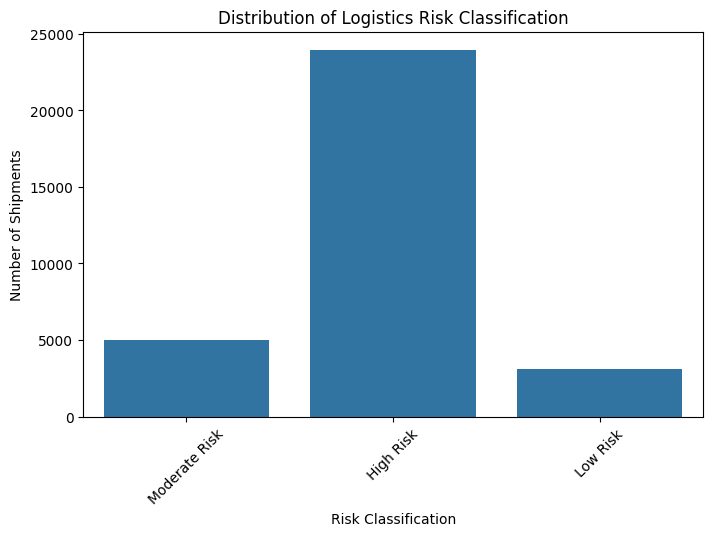

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="risk_classification"
)

plt.title("Distribution of Logistics Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.show()

In [15]:
print(
    "Missing values in risk_classification:",
    df["risk_classification"].isnull().sum()
)

Missing values in risk_classification: 0


In [17]:
print("Data type:", df["risk_classification"].dtype)

Data type: object


In [18]:
features = [
    "fuel_consumption_rate",
    "eta_variation_hours",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "disruption_likelihood_score",
    "delivery_time_deviation"
]

target = "risk_classification"

print("Number of features:", len(features))
print("Target:", target)

Number of features: 19
Target: risk_classification


In [19]:
model_df = df[features + [target]].copy()

print("Modeling dataset shape:", model_df.shape)
model_df.head()

Modeling dataset shape: (32065, 20)


,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delivery_time_deviation,risk_classification
0,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.359066,4.289160,456.503853,0.986064,2.128009,100.772854,0.574400,1.182116,0.502006,0.033843,0.978599,0.506152,9.110682,Moderate Risk
1,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.230660,7.018373,640.408205,0.463233,12.608166,5313.738114,-9.753493,9.611988,0.966774,0.201725,0.918586,0.980784,8.175281,High Risk
2,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.027210,9.605064,155.749314,0.598561,14.124452,1595.049146,-6.491034,6.570431,0.945627,0.264045,0.394215,0.998633,1.283594,High Risk
3,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.616619,8.899616,104.317961,0.742735,3.818972,2530.431941,-0.151276,0.548952,4.674035,0.362885,0.905444,0.993320,9.304897,High Risk
4,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.952385,0.061760,977.222528,0.431088,14.001491,2146.190197,2.429448,8.861443,3.445429,0.016957,0.258702,0.912433,7.752484,High Risk


**Step 3 — Exploratory Data Analysis (EDA)**

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("\nNumerical columns:")
print(numeric_cols)

Number of numerical columns: 24

Numerical columns:
['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation']


In [21]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,32065.0,38.023589,6.917909,3.000000e+01,31.280550,36.413820,44.453655,50.000000
vehicle_gps_longitude,32065.0,-90.116648,17.369244,-1.200000e+02,-106.253913,-86.293414,-73.079367,-70.000000
fuel_consumption_rate,32065.0,8.011735,4.264960,5.000000e+00,5.019984,5.636036,9.669944,19.999875
eta_variation_hours,32065.0,2.893068,2.274044,-1.999993e+00,1.185744,3.882059,4.884355,5.000000
traffic_congestion_level,32065.0,4.991493,3.532048,1.091633e-09,1.474720,4.981244,8.534902,9.999999
warehouse_inventory_level,32065.0,299.254732,323.443513,1.322210e-12,16.051635,157.288022,540.597991,999.999298
loading_unloading_time,32065.0,2.291669,1.554202,5.000000e-01,0.774798,1.917121,3.734188,5.000000
handling_equipment_availability,32065.0,0.302695,0.325915,4.565769e-16,0.017108,0.159515,0.553595,0.999999
order_fulfillment_status,32065.0,0.600740,0.345672,1.317764e-06,0.277096,0.680553,0.938160,1.000000
weather_condition_severity,32065.0,0.497608,0.353285,4.536949e-09,0.144014,0.496178,0.849823,1.000000


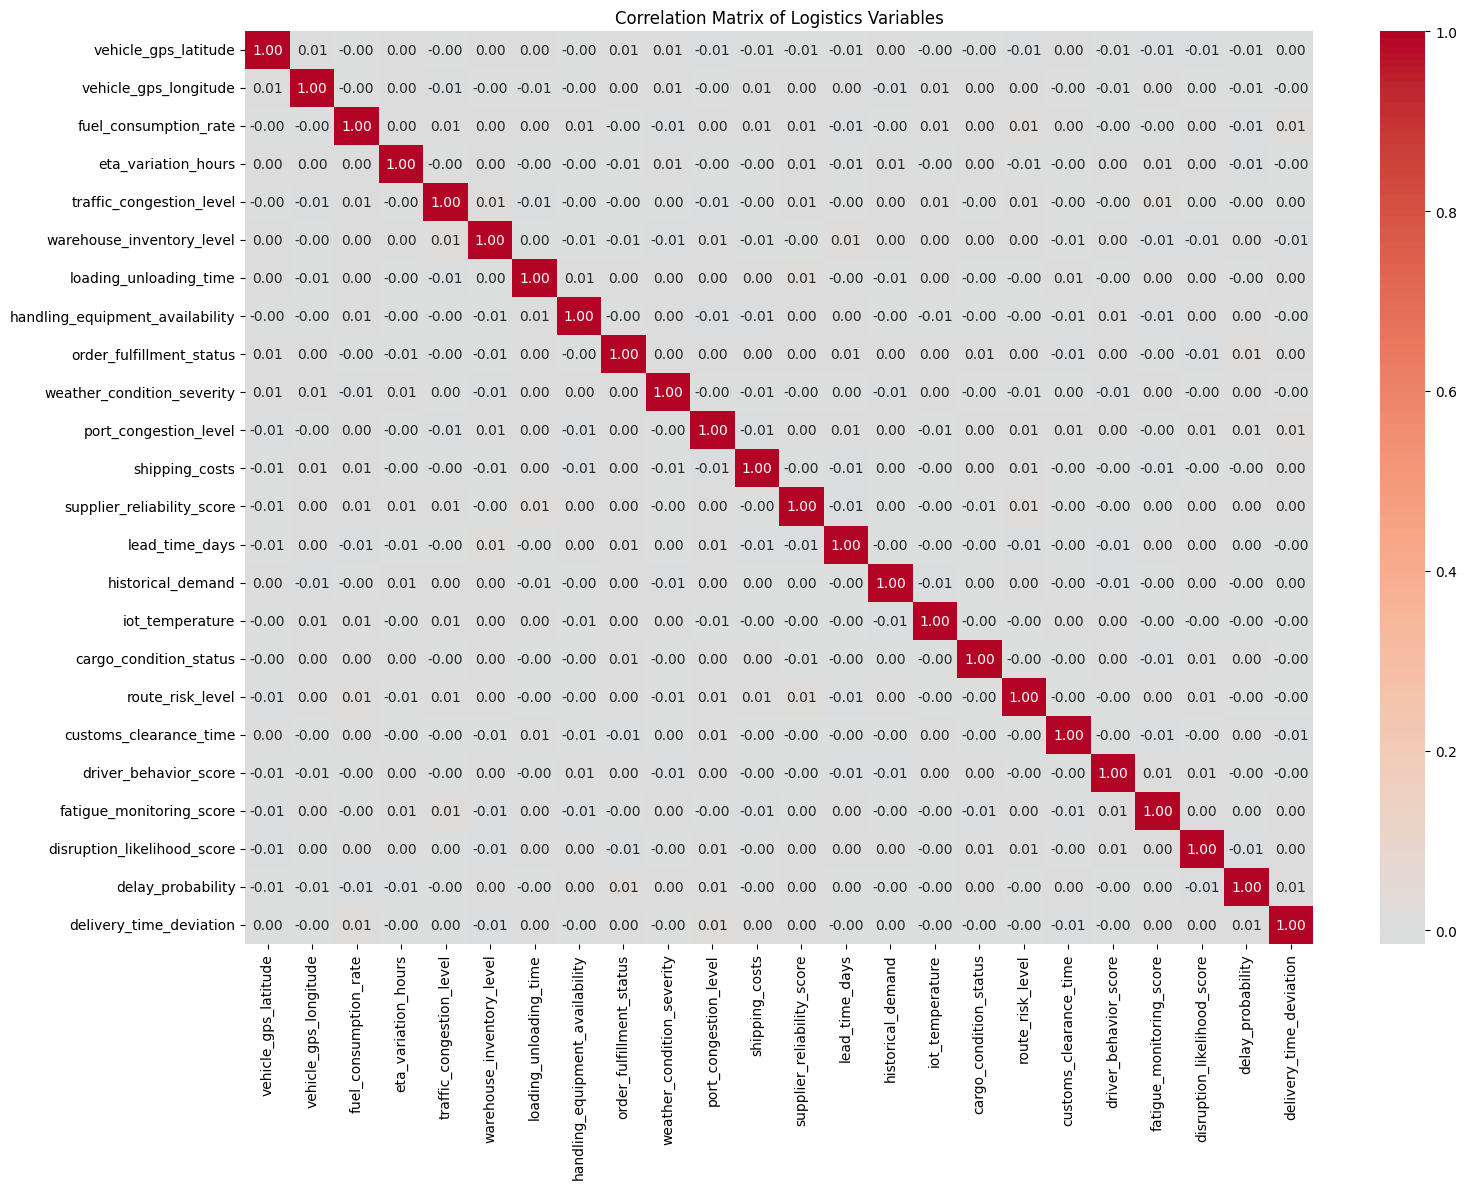

In [22]:
correlation = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Logistics Variables")
plt.tight_layout()
plt.show()

In [23]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculate correlation matrix
correlation = df[numeric_cols].corr()

# Calculate correlations with delivery_time_deviation
delivery_corr = (
    correlation["delivery_time_deviation"]
    .sort_values(ascending=False)
)

print("Correlation with delivery_time_deviation:")
print(delivery_corr)

Correlation with delivery_time_deviation:
delivery_time_deviation            1.000000
fuel_consumption_rate              0.012495
port_congestion_level              0.010612
delay_probability                  0.005530
supplier_reliability_score         0.004384
fatigue_monitoring_score           0.003491
loading_unloading_time             0.003375
order_fulfillment_status           0.003329
disruption_likelihood_score        0.002622
shipping_costs                     0.002504
historical_demand                  0.000615
traffic_congestion_level           0.000510
vehicle_gps_latitude               0.000416
route_risk_level                  -0.000076
weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   

In [24]:
print("\nStrongest positive correlations:")
print(delivery_corr.head(10))

print("\nStrongest negative correlations:")
print(delivery_corr.tail(10))


Strongest positive correlations:
delivery_time_deviation        1.000000
fuel_consumption_rate          0.012495
port_congestion_level          0.010612
delay_probability              0.005530
supplier_reliability_score     0.004384
fatigue_monitoring_score       0.003491
loading_unloading_time         0.003375
order_fulfillment_status       0.003329
disruption_likelihood_score    0.002622
shipping_costs                 0.002504
Name: delivery_time_deviation, dtype: float64

Strongest negative correlations:
weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   -0.004639
warehouse_inventory_level         -0.007463
customs_clearance_time            -0.009244
Name: delivery_time_deviation, dtype: float64


In [25]:
risk_summary = df.groupby("risk_classification")[numeric_cols].mean()

risk_summary

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
risk_classification,,,,,,,,,,,,,,,,,,,,,
High Risk,38.006742,-90.077868,8.017668,2.896003,4.988920,297.787318,2.292173,0.303670,0.598699,0.497523,...,6020.723276,-0.006685,0.298241,7.009057,2.298554,0.498836,0.601159,0.949070,0.698595,5.184047
Low Risk,38.162414,-90.149512,7.965043,2.883368,4.950268,311.681844,2.294778,0.299065,0.599271,0.503369,...,6007.759661,0.123608,0.284234,6.933816,2.299014,0.490315,0.597676,0.143397,0.706961,5.118329
Moderate Risk,38.017929,-90.281552,8.012364,2.885062,5.029374,298.553763,2.287332,0.300291,0.611402,0.494438,...,6036.946828,0.241846,0.300796,7.005123,2.284793,0.501279,0.601487,0.518606,0.696487,5.183886


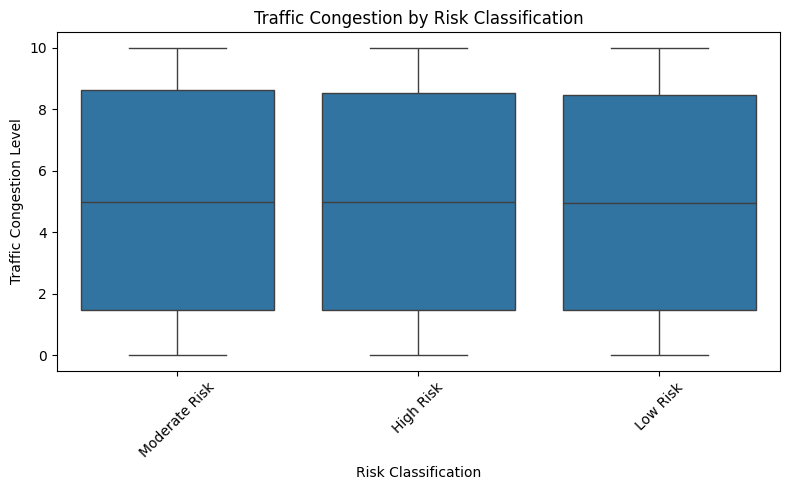

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_classification",
    y="traffic_congestion_level"
)

plt.title("Traffic Congestion by Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Traffic Congestion Level")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

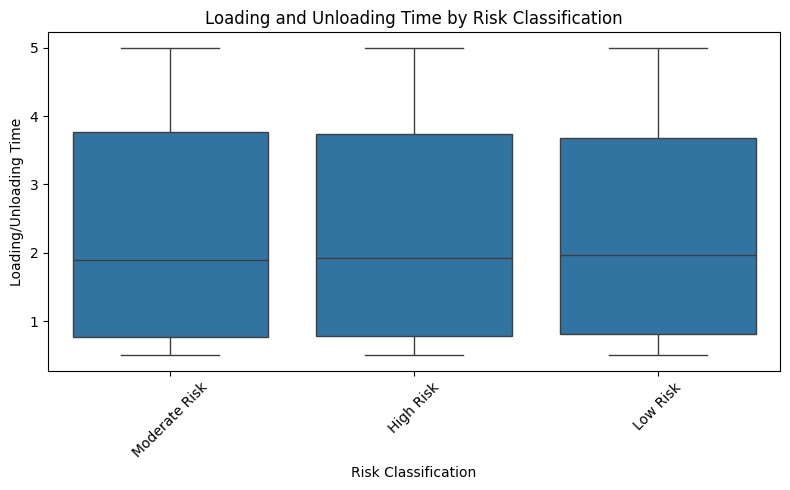

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_classification",
    y="loading_unloading_time"
)

plt.title("Loading and Unloading Time by Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Loading/Unloading Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

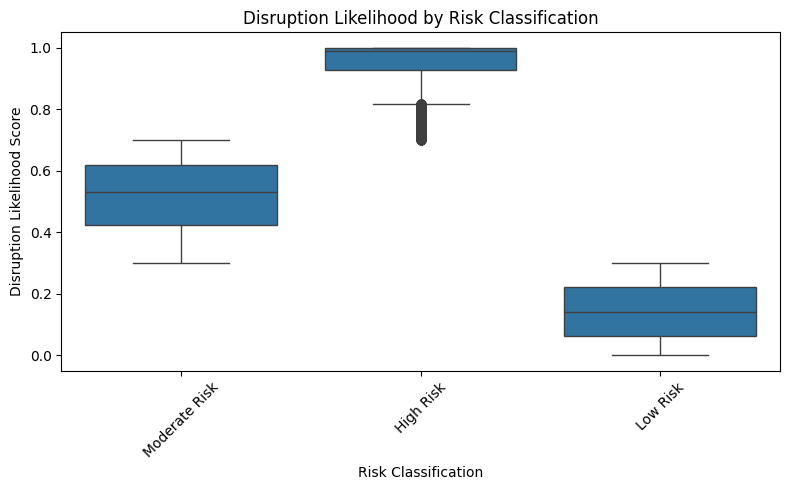

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_classification",
    y="disruption_likelihood_score"
)

plt.title("Disruption Likelihood by Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Disruption Likelihood Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

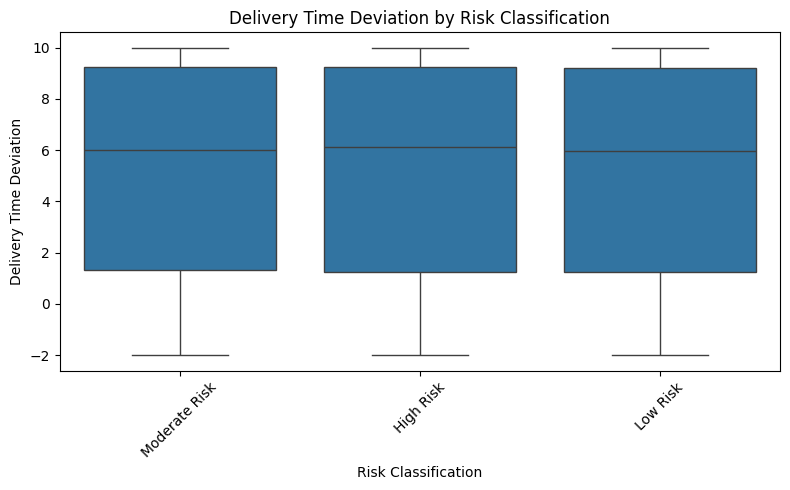

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_classification",
    y="delivery_time_deviation"
)

plt.title("Delivery Time Deviation by Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Delivery Time Deviation")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(categorical_cols)

['timestamp', 'risk_classification']


In [31]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== timestamp =====
timestamp
2021-01-01 00:00:00    1
2021-01-01 01:00:00    1
2021-01-01 02:00:00    1
2021-01-01 03:00:00    1
2021-01-01 04:00:00    1
                      ..
2024-08-28 20:00:00    1
2024-08-28 21:00:00    1
2024-08-28 22:00:00    1
2024-08-28 23:00:00    1
2024-08-29 00:00:00    1
Name: count, Length: 32065, dtype: int64

===== risk_classification =====
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [32]:
pd.crosstab(
    df["route_risk_level"],
    df["risk_classification"],
    normalize="index"
) * 100

risk_classification,High Risk,Low Risk,Moderate Risk
route_risk_level,,,
0.000050,100.0,0.0,0.0
0.000090,0.0,0.0,100.0
0.000091,100.0,0.0,0.0
0.000101,100.0,0.0,0.0
0.000144,100.0,0.0,0.0
...,...,...,...
10.000000,100.0,0.0,0.0
10.000000,100.0,0.0,0.0
10.000000,100.0,0.0,0.0


In [33]:
pd.crosstab(
    df["weather_condition_severity"],
    df["risk_classification"],
    normalize="index"
) * 100

risk_classification,High Risk,Low Risk,Moderate Risk
weather_condition_severity,,,
4.536949e-09,100.0,0.0,0.0
9.145892e-09,100.0,0.0,0.0
1.256987e-08,100.0,0.0,0.0
1.380562e-08,100.0,0.0,0.0
7.347305e-08,100.0,0.0,0.0
...,...,...,...
9.999999e-01,100.0,0.0,0.0
9.999999e-01,100.0,0.0,0.0
1.000000e+00,0.0,0.0,100.0


In [34]:
print(
    pd.crosstab(
        df["delay_probability"],
        df["risk_classification"],
        normalize="index"
    ).round(3)
)

risk_classification  High Risk  Low Risk  Moderate Risk
delay_probability                                      
0.000003                   1.0       0.0            0.0
0.000008                   1.0       0.0            0.0
0.000021                   1.0       0.0            0.0
0.000027                   1.0       0.0            0.0
0.000028                   1.0       0.0            0.0
...                        ...       ...            ...
1.000000                   1.0       0.0            0.0
1.000000                   1.0       0.0            0.0
1.000000                   1.0       0.0            0.0
1.000000                   0.0       1.0            0.0
1.000000                   1.0       0.0            0.0

[32065 rows x 3 columns]


**Step 4 — Data Preparation for Machine Learning****Step 4 — Data Preparation for Machine Learning**

In [35]:
print("Target classes:")
print(df["risk_classification"].unique())

print("\nClass distribution:")
print(df["risk_classification"].value_counts())

Target classes:
['Moderate Risk' 'High Risk' 'Low Risk']

Class distribution:
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [36]:
features = [
    "fuel_consumption_rate",
    "eta_variation_hours",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "cargo_condition_status",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "disruption_likelihood_score",
    "delivery_time_deviation"
]

target = "risk_classification"

X = df[features].copy()
y = df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32065, 20)
Target shape: (32065,)


In [37]:
print("Numerical features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical features:
['fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delivery_time_deviation']

Categorical features:
[]


In [38]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 20
Number of categorical features: 0

Numerical features:
['fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delivery_time_deviation']

Categorical features:
[]


In [39]:
print("Missing values in features:")
print(X.isnull().sum().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
0

Missing values in target:
0


In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
['High Risk' 'Low Risk' 'Moderate Risk']

Encoded classes:
[0 1 2]


In [41]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Target encoding mapping:")
print(label_mapping)

Target encoding mapping:
{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Moderate Risk': np.int64(2)}


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (25652, 20)
Testing features: (6413, 20)
Training target: (25652,)
Testing target: (6413,)


In [44]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (25652, 20)
Processed testing data shape: (6413, 20)


In [45]:
print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("\nTraining shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>

Training shape: (25652, 20)
Testing shape: (6413, 20)


In [46]:
print("Training target distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Training target distribution:
0    0.746725
1    0.096990
2    0.156284
Name: proportion, dtype: float64

Testing target distribution:
0    0.746764
1    0.096990
2    0.156245
Name: proportion, dtype: float64


In [47]:
stratify=y_encoded

**Step 5 — Train the Logistic Regression Model**

In [48]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [49]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


In [50]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [51]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully.
Number of predictions: 6413


In [52]:
print("First 20 predictions:")
print(y_pred_logistic[:20])

First 20 predictions:
[0 0 2 0 2 0 0 2 0 0 0 0 0 1 0 0 0 2 0 0]


In [53]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.9989


In [54]:
print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy * 100:.2f}%"
)

Logistic Regression Accuracy: 99.89%


In [55]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Classification Report:

               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      4789
     Low Risk       1.00      1.00      1.00       622
Moderate Risk       1.00      1.00      1.00      1002

     accuracy                           1.00      6413
    macro avg       1.00      1.00      1.00      6413
 weighted avg       1.00      1.00      1.00      6413



In [56]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[4787    0    2]
 [   0  620    2]
 [   0    3  999]]


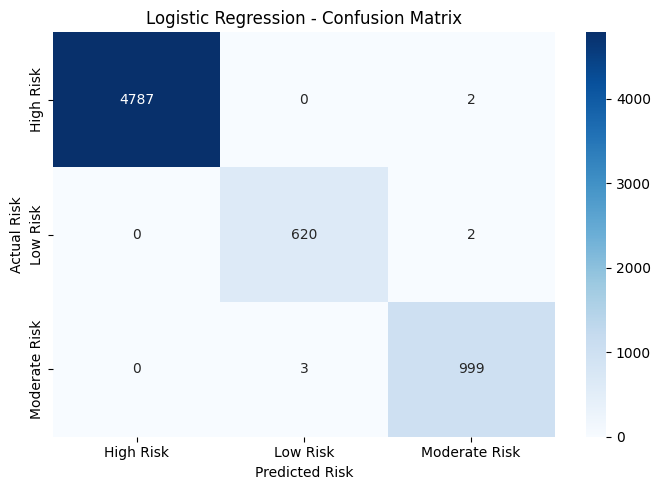

In [57]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [58]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic,
    multi_class="ovr"
)

print(f"Logistic Regression ROC-AUC: {logistic_roc_auc:.4f}")

Logistic Regression ROC-AUC: 1.0000


In [59]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "ROC_AUC": logistic_roc_auc
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.9989084671760486, 'ROC_AUC': 0.9999925264084645}


**Step 6 — Train the Decision Tree Model**

In [64]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [61]:
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

print(decision_tree)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)


In [62]:
decision_tree.fit(
    X_train_processed,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [63]:
y_pred_tree = decision_tree.predict(
    X_test_processed
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_tree))

Predictions generated successfully.
Number of predictions: 6413


In [65]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(
    f"Decision Tree Accuracy: "
    f"{tree_accuracy * 100:.2f}%"
)

Decision Tree Accuracy: 100.00%


In [66]:
print("Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=label_encoder.classes_
    )
)

Decision Tree Classification Report:

               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      4789
     Low Risk       1.00      1.00      1.00       622
Moderate Risk       1.00      1.00      1.00      1002

     accuracy                           1.00      6413
    macro avg       1.00      1.00      1.00      6413
 weighted avg       1.00      1.00      1.00      6413



In [67]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[4789    0    0]
 [   0  622    0]
 [   0    0 1002]]


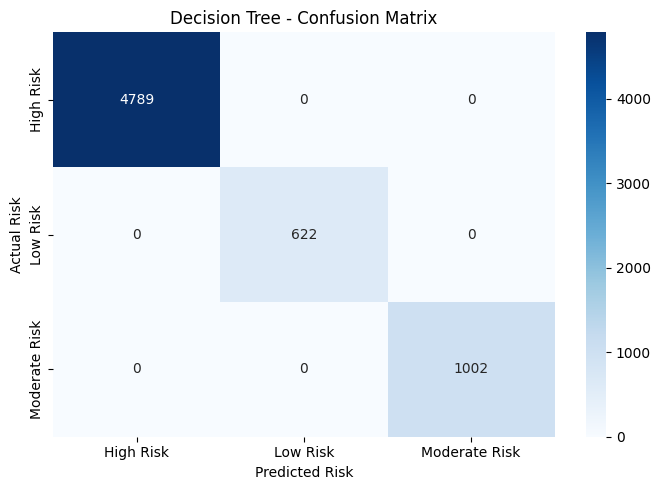

In [68]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [69]:
y_prob_tree = decision_tree.predict_proba(
    X_test_processed
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree,
    multi_class="ovr"
)

print(
    f"Decision Tree ROC-AUC: "
    f"{tree_roc_auc:.4f}"
)

Decision Tree ROC-AUC: 1.0000


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1-score:  {tree_f1:.4f}")
print(f"ROC-AUC:   {tree_roc_auc:.4f}")

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
ROC-AUC:   1.0000


In [71]:
tree_results = {
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Precision": tree_precision,
    "Recall": tree_recall,
    "F1_Score": tree_f1,
    "ROC_AUC": tree_roc_auc
}

print(tree_results)

{'Model': 'Decision Tree', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1_Score': 1.0, 'ROC_AUC': 1.0}


In [72]:
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

Tree depth: 2
Number of leaves: 3


**Step 7 — Train the Random Forest Model**

In [73]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [74]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print(random_forest)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)


In [77]:
random_forest.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [78]:
y_pred_rf = random_forest.predict(
    X_test_processed
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully.
Number of predictions: 6413


In [79]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy * 100:.2f}%"
)

Random Forest Accuracy: 100.00%


In [80]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Classification Report:

               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      4789
     Low Risk       1.00      1.00      1.00       622
Moderate Risk       1.00      1.00      1.00      1002

     accuracy                           1.00      6413
    macro avg       1.00      1.00      1.00      6413
 weighted avg       1.00      1.00      1.00      6413



In [81]:
rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [82]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[4789    0    0]
 [   0  622    0]
 [   0    0 1002]]


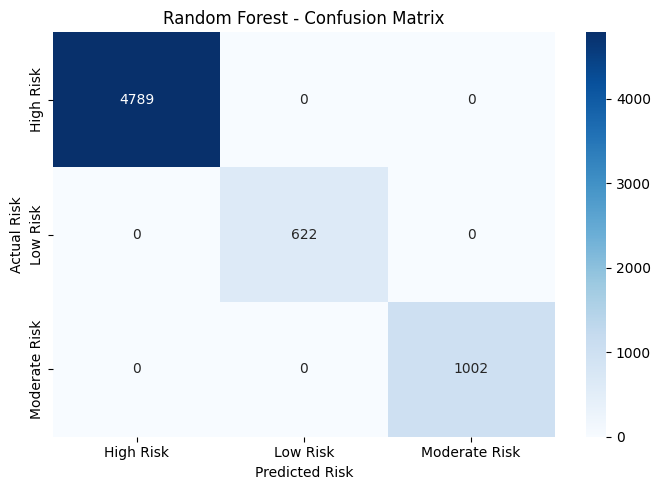

In [83]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [84]:
y_prob_rf = random_forest.predict_proba(
    X_test_processed
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr"
)

print(
    f"Random Forest ROC-AUC: "
    f"{rf_roc_auc:.4f}"
)

Random Forest ROC-AUC: 1.0000


In [85]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1_Score": rf_f1,
    "ROC_AUC": rf_roc_auc
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1_Score': 1.0, 'ROC_AUC': 1.0}


In [86]:
print("Number of trees:", len(random_forest.estimators_))

Number of trees: 200


In [87]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": precision_score(
            y_test,
            y_pred_logistic,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            y_pred_logistic,
            average="weighted"
        ),
        "F1_Score": f1_score(
            y_test,
            y_pred_logistic,
            average="weighted"
        ),
        "ROC_AUC": logistic_roc_auc
    },
    tree_results,
    rf_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.998908,0.99891,0.998908,0.998909,0.999993
1,Decision Tree,1.000000,1.00000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.00000,1.000000,1.000000,1.000000


In [88]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.9989,0.9989,0.9989,0.9989,1.0
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0


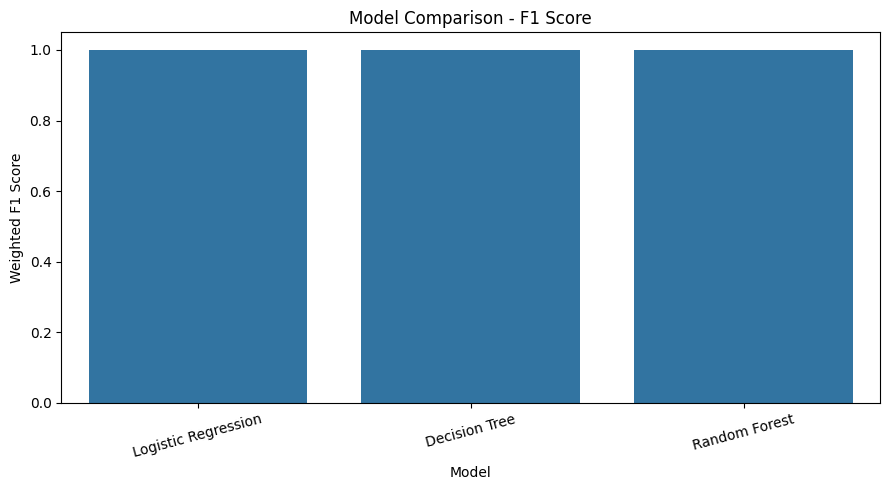

In [89]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="F1_Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

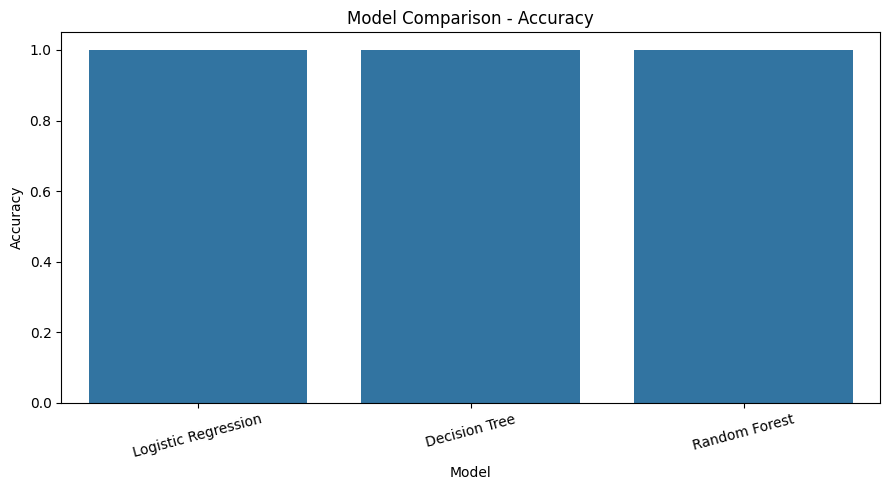

In [90]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Step 8 — Cross-Validation and Hyperparameter Tuning**

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [14]:
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-4\cleaned_logistics_data.csv")
print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("5-Fold Stratified Cross-Validation created.")

Dataset loaded successfully.
Dataset shape: (32065, 26)
5-Fold Stratified Cross-Validation created.


In [15]:
features = [
    "fuel_consumption_rate",
    "eta_variation_hours",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "cargo_condition_status",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "disruption_likelihood_score",
    "delivery_time_deviation"
]

target = "risk_classification"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32065, 20)
y shape: (32065,)


In [16]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delivery_time_deviation']

Categorical features:
[]


In [17]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target classes:")
print(label_encoder.classes_)

print("\nTarget encoding:")
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

Target classes:
['High Risk' 'Low Risk' 'Moderate Risk']

Target encoding:
{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Moderate Risk': np.int64(2)}


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (25652, 20)
y_train: (25652,)

Testing data:
X_test: (6413, 20)
y_test: (6413,)


In [20]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (25652, 20)
Processed testing data: (6413, 20)


In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [22]:
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [23]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("All three models created successfully.")

All three models created successfully.


In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [25]:
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Logistic Regression CV F1 Scores:")
print(logistic_cv_scores)

print(
    f"\nMean CV F1 Score: "
    f"{logistic_cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{logistic_cv_scores.std():.4f}"
)

Logistic Regression CV F1 Scores:
[0.99902498 0.99727103 0.99687755 0.99785391 0.99591152]

Mean CV F1 Score: 0.9974
Standard Deviation: 0.0010


In [26]:
tree_cv_scores = cross_val_score(
    decision_tree,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Decision Tree CV F1 Scores:")
print(tree_cv_scores)

print(
    f"\nMean CV F1 Score: "
    f"{tree_cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{tree_cv_scores.std():.4f}"
)

Decision Tree CV F1 Scores:
[1.         1.         1.         1.         0.99980512]

Mean CV F1 Score: 1.0000
Standard Deviation: 0.0001


In [27]:
rf_cv_scores = cross_val_score(
    random_forest,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Random Forest CV F1 Scores:")
print(rf_cv_scores)

print(
    f"\nMean CV F1 Score: "
    f"{rf_cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{rf_cv_scores.std():.4f}"
)

Random Forest CV F1 Scores:
[1. 1. 1. 1. 1.]

Mean CV F1 Score: 1.0000
Standard Deviation: 0.0000


In [28]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean_CV_F1": [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Std_CV_F1": [
        logistic_cv_scores.std(),
        tree_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_comparison = cv_comparison.round(4)

print("Cross-Validation Comparison:")
display(cv_comparison)

Cross-Validation Comparison:


,Model,Mean_CV_F1,Std_CV_F1
0,Logistic Regression,0.9974,0.0010
1,Decision Tree,1.0000,0.0001
2,Random Forest,1.0000,0.0000


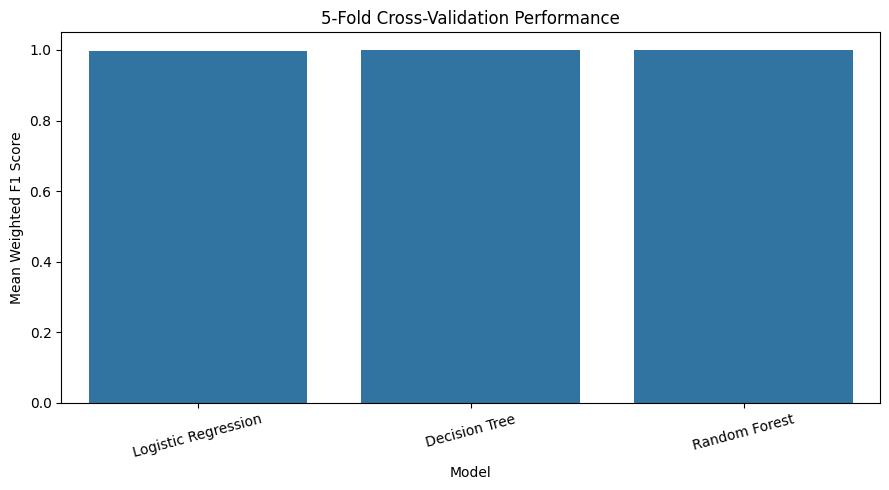

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.barplot(
    data=cv_comparison,
    x="Model",
    y="Mean_CV_F1"
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean Weighted F1 Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [30]:
tree_param_grid = {
    "max_depth": [5, 8, 10, 12, 15],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10]
}

print("Decision Tree parameter grid created.")

Decision Tree parameter grid created.


In [31]:
tree_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=tree_param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [32]:
tree_grid_search.fit(
    X_train_processed,
    y_train
)

print("Decision Tree hyperparameter tuning completed.")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Decision Tree hyperparameter tuning completed.


In [33]:
print("Best Decision Tree parameters:")
print(tree_grid_search.best_params_)

print(
    f"\nBest Decision Tree CV F1 Score: "
    f"{tree_grid_search.best_score_:.4f}"
)

Best Decision Tree parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Decision Tree CV F1 Score: 1.0000


In [35]:
best_tree = tree_grid_search.best_estimator_

print("Optimized Decision Tree:")
print(best_tree)

Optimized Decision Tree:
DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)


In [36]:
y_pred_best_tree = best_tree.predict(
    X_test_processed
)

best_tree_accuracy = accuracy_score(
    y_test,
    y_pred_best_tree
)

best_tree_precision = precision_score(
    y_test,
    y_pred_best_tree,
    average="weighted"
)

best_tree_recall = recall_score(
    y_test,
    y_pred_best_tree,
    average="weighted"
)

best_tree_f1 = f1_score(
    y_test,
    y_pred_best_tree,
    average="weighted"
)

best_tree_roc_auc = roc_auc_score(
    y_test,
    best_tree.predict_proba(X_test_processed),
    multi_class="ovr"
)

print(f"Accuracy : {best_tree_accuracy:.4f}")
print(f"Precision: {best_tree_precision:.4f}")
print(f"Recall   : {best_tree_recall:.4f}")
print(f"F1-score : {best_tree_f1:.4f}")
print(f"ROC-AUC  : {best_tree_roc_auc:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000


In [3]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, 16],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

print("Random Forest parameter grid created.")

Random Forest parameter grid created.


In [49]:
logistic_model.fit(
    X_train_processed,
    y_train
)

decision_tree.fit(
    X_train_processed,
    y_train
)

random_forest.fit(
    X_train_processed,
    y_train
)

print("Original models trained successfully.")

Original models trained successfully.


**Step 9 — Final Model Evaluation & Feature Importance**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-4\cleaned_logistics_data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (32065, 26)


In [36]:
print("Risk classification distribution:")
print(df["risk_classification"].value_counts())

print("\nDisruption likelihood statistics:")
print(df["disruption_likelihood_score"].describe())

Risk classification distribution:
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64

Disruption likelihood statistics:
count    32065.000000
mean         0.803656
std          0.279185
min          0.000048
25%          0.693739
50%          0.958128
75%          0.998746
max          1.000000
Name: disruption_likelihood_score, dtype: float64


In [37]:
print("\nRisk classification vs disruption likelihood:")

print(
    df.groupby("risk_classification")[
        "disruption_likelihood_score"
    ].agg(
        ["min", "max", "mean", "std"]
    )
)


Risk classification vs disruption likelihood:
                          min       max      mean       std
risk_classification                                        
High Risk            0.700140  1.000000  0.949070  0.076058
Low Risk             0.000048  0.299811  0.143397  0.089059
Moderate Risk        0.300146  0.699947  0.518606  0.115462


In [38]:
print(
    pd.crosstab(
        pd.cut(
            df["disruption_likelihood_score"],
            bins=10
        ),
        df["risk_classification"],
        normalize="index"
    ).round(3)
)

risk_classification          High Risk  Low Risk  Moderate Risk
disruption_likelihood_score                                    
(-0.000952, 0.1]                   0.0       1.0            0.0
(0.1, 0.2]                         0.0       1.0            0.0
(0.2, 0.3]                         0.0       1.0            0.0
(0.3, 0.4]                         0.0       0.0            1.0
(0.4, 0.5]                         0.0       0.0            1.0
(0.5, 0.6]                         0.0       0.0            1.0
(0.6, 0.7]                         0.0       0.0            1.0
(0.7, 0.8]                         1.0       0.0            0.0
(0.8, 0.9]                         1.0       0.0            0.0
(0.9, 1.0]                         1.0       0.0            0.0


In [39]:
potential_leakage = [
    "delay_probability",
    "disruption_likelihood_score",
    "delivery_time_deviation",
    "eta_variation_hours"
]

for col in potential_leakage:
    print("\n" + "=" * 60)
    print("Feature:", col)
    print(
        df.groupby("risk_classification")[col]
        .mean()
    )


Feature: delay_probability
risk_classification
High Risk        0.698595
Low Risk         0.706961
Moderate Risk    0.696487
Name: delay_probability, dtype: float64

Feature: disruption_likelihood_score
risk_classification
High Risk        0.949070
Low Risk         0.143397
Moderate Risk    0.518606
Name: disruption_likelihood_score, dtype: float64

Feature: delivery_time_deviation
risk_classification
High Risk        5.184047
Low Risk         5.118329
Moderate Risk    5.183886
Name: delivery_time_deviation, dtype: float64

Feature: eta_variation_hours
risk_classification
High Risk        2.896003
Low Risk         2.883368
Moderate Risk    2.885062
Name: eta_variation_hours, dtype: float64


In [40]:
for col in potential_leakage:
    
    print("\n" + "=" * 70)
    print("Feature:", col)
    
    print(
        pd.crosstab(
            df[col],
            df["risk_classification"],
            normalize="index"
        ).head(20)
    )


Feature: delay_probability
risk_classification  High Risk  Low Risk  Moderate Risk
delay_probability                                      
0.000003                   1.0       0.0            0.0
0.000008                   1.0       0.0            0.0
0.000021                   1.0       0.0            0.0
0.000027                   1.0       0.0            0.0
0.000028                   1.0       0.0            0.0
0.000031                   1.0       0.0            0.0
0.000031                   0.0       1.0            0.0
0.000035                   1.0       0.0            0.0
0.000041                   1.0       0.0            0.0
0.000044                   1.0       0.0            0.0
0.000046                   0.0       1.0            0.0
0.000049                   0.0       0.0            1.0
0.000054                   0.0       1.0            0.0
0.000056                   0.0       0.0            1.0
0.000071                   0.0       0.0            1.0
0.000073            

In [41]:
features = [
    "fuel_consumption_rate",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "cargo_condition_status",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score"
]

target = "risk_classification"

X = df[features].copy()
y = df[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (32065, 17)
Target: (32065,)


In [6]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delivery_time_deviation']

Categorical features:
[]


In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Risk classes:")
print(label_encoder.classes_)

print("\nEncoding:")
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(
                label_encoder.classes_
            )
        )
    )
)

Risk classes:
['High Risk' 'Low Risk' 'Moderate Risk']

Encoding:
{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Moderate Risk': np.int64(2)}


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25652, 20)
Testing data: (6413, 20)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (25652, 20)
Processed testing data: (6413, 20)


In [10]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test_processed
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [11]:
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree.fit(
    X_train_processed,
    y_train
)

y_pred_tree = decision_tree.predict(
    X_test_processed
)

print("Decision Tree trained.")

Decision Tree trained.


In [12]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_processed,
    y_train
)

y_pred_rf = random_forest.predict(
    X_test_processed
)

print("Random Forest trained.")

Random Forest trained.


In [13]:
def calculate_metrics(model, predictions):
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )
    
    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )
    
    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )
    
    probabilities = model.predict_proba(
        X_test_processed
    )
    
    roc_auc = roc_auc_score(
        y_test,
        probabilities,
        multi_class="ovr"
    )
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    }

In [14]:
logistic_metrics = calculate_metrics(
    logistic_model,
    y_pred_logistic
)

tree_metrics = calculate_metrics(
    decision_tree,
    y_pred_tree
)

rf_metrics = calculate_metrics(
    random_forest,
    y_pred_rf
)

print("Metrics calculated successfully.")

Metrics calculated successfully.


In [15]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_metrics
    },
    {
        "Model": "Decision Tree",
        **tree_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    }
])

final_model_comparison = final_model_comparison.round(4)

display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.9989,0.9989,0.9989,0.9989,1.0
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0


In [16]:
best_model_row = final_model_comparison.loc[
    final_model_comparison["F1_Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print("Best Model:", best_model_name)

print(
    f"Best F1-score: "
    f"{best_model_row['F1_Score']:.4f}"
)

Best Model: Decision Tree
Best F1-score: 1.0000


In [17]:
if best_model_name == "Logistic Regression":
    final_model = logistic_model

elif best_model_name == "Decision Tree":
    final_model = decision_tree

elif best_model_name == "Random Forest":
    final_model = random_forest

else:
    raise ValueError(
        "Unexpected model name."
    )

print("Final model selected successfully.")
print(final_model)

Final model selected successfully.
DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)


In [18]:
y_pred_final = final_model.predict(
    X_test_processed
)

print(
    "Final predictions generated:",
    len(y_pred_final)
)

Final predictions generated: 6413


In [19]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      4789
     Low Risk       1.00      1.00      1.00       622
Moderate Risk       1.00      1.00      1.00      1002

     accuracy                           1.00      6413
    macro avg       1.00      1.00      1.00      6413
 weighted avg       1.00      1.00      1.00      6413



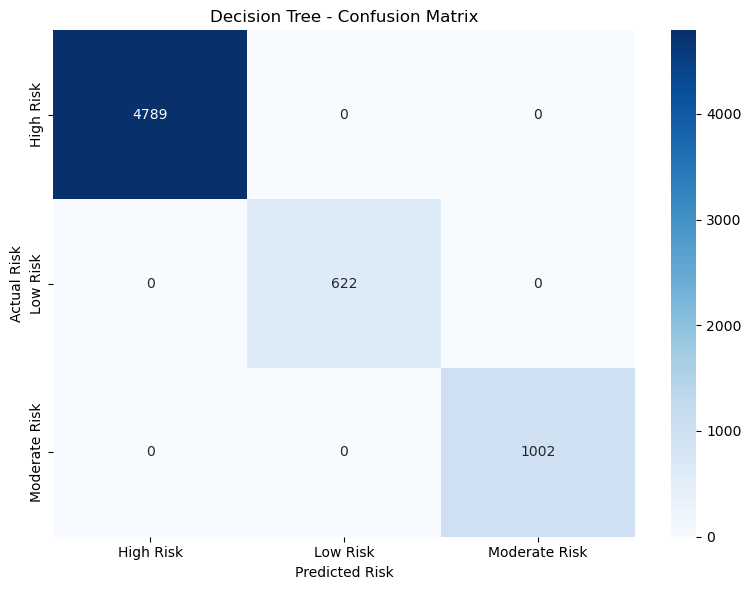

In [20]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"{best_model_name} - Confusion Matrix"
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [21]:
if hasattr(final_model, "feature_importances_"):

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    importance_values = (
        final_model.feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("Top 20 Features:")
    display(
        feature_importance.head(20)
    )

else:
    print(
        "The selected model does not provide "
        "feature importance."
    )

Top 20 Features:


,Feature,Importance
18,num__disruption_likelihood_score,1.0
0,num__fuel_consumption_rate,0.0
1,num__eta_variation_hours,0.0
17,num__fatigue_monitoring_score,0.0
16,num__driver_behavior_score,0.0
15,num__customs_clearance_time,0.0
14,num__route_risk_level,0.0
13,num__cargo_condition_status,0.0
12,num__iot_temperature,0.0
11,num__historical_demand,0.0


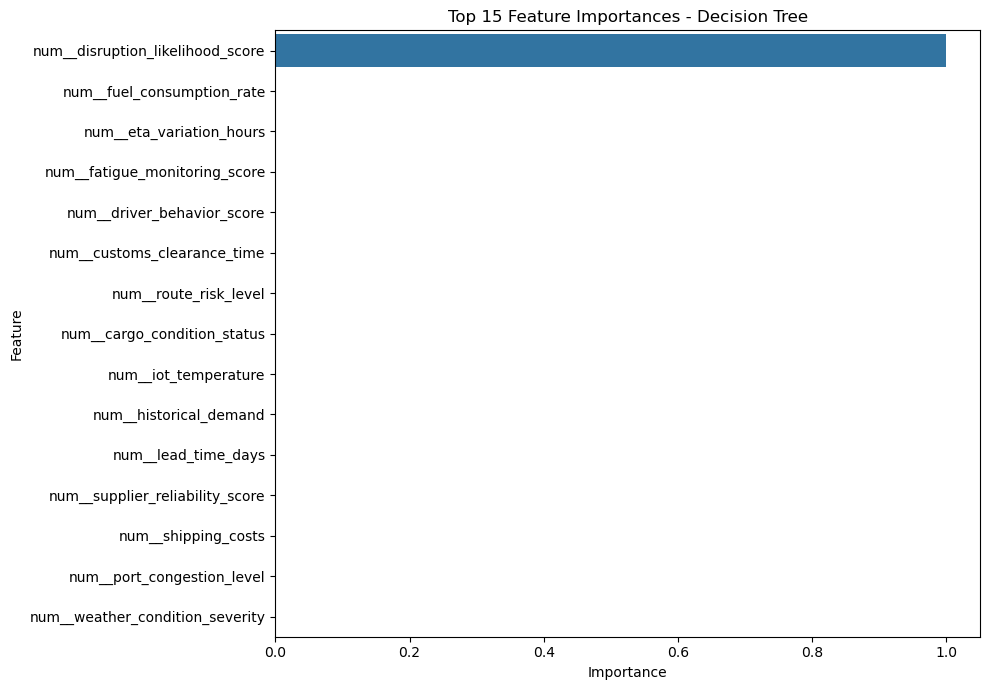

In [22]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    f"Top 15 Feature Importances - {best_model_name}"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Step 10 — Logistics Optimization Strategies**

In [42]:
# STEP 10.1 - LEAKAGE-FREE FEATURE SELECTION

features_clean = [
    "fuel_consumption_rate",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "cargo_condition_status",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score"
]

target_clean = "risk_classification"

X_clean = df[features_clean].copy()
y_clean = df[target_clean].copy()

print("Number of features:", len(features_clean))
print("X shape:", X_clean.shape)
print("y shape:", y_clean.shape)

Number of features: 17
X shape: (32065, 17)
y shape: (32065,)


In [43]:
numeric_features_clean = X_clean.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_clean = X_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features_clean)

print("\nCategorical features:")
print(categorical_features_clean)

Numerical features:
['fuel_consumption_rate', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score']

Categorical features:
[]


In [44]:
label_encoder_clean = LabelEncoder()

y_clean_encoded = label_encoder_clean.fit_transform(
    y_clean
)

print("Risk classes:")
print(label_encoder_clean.classes_)

print("\nEncoding:")
print(
    dict(
        zip(
            label_encoder_clean.classes_,
            label_encoder_clean.transform(
                label_encoder_clean.classes_
            )
        )
    )
)

Risk classes:
['High Risk' 'Low Risk' 'Moderate Risk']

Encoding:
{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Moderate Risk': np.int64(2)}


In [45]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_clean_encoded
)

print("Training data:", X_train_clean.shape)
print("Testing data:", X_test_clean.shape)

Training data: (25652, 17)
Testing data: (6413, 17)


In [46]:
preprocessor_clean = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_clean
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_clean
        )
    ]
)

X_train_clean_processed = preprocessor_clean.fit_transform(
    X_train_clean
)

X_test_clean_processed = preprocessor_clean.transform(
    X_test_clean
)

print(
    "Processed training shape:",
    X_train_clean_processed.shape
)

print(
    "Processed testing shape:",
    X_test_clean_processed.shape
)

Processed training shape: (25652, 17)
Processed testing shape: (6413, 17)


In [47]:
logistic_clean = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_clean.fit(
    X_train_clean_processed,
    y_train_clean
)

pred_logistic_clean = logistic_clean.predict(
    X_test_clean_processed
)

print("Logistic Regression completed.")

Logistic Regression completed.


In [48]:
tree_clean = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree_clean.fit(
    X_train_clean_processed,
    y_train_clean
)

pred_tree_clean = tree_clean.predict(
    X_test_clean_processed
)

print("Decision Tree completed.")

Decision Tree completed.


In [49]:
rf_clean = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(
    X_train_clean_processed,
    y_train_clean
)

pred_rf_clean = rf_clean.predict(
    X_test_clean_processed
)

print("Random Forest completed.")

Random Forest completed.


In [50]:
def evaluate_clean_model(model, predictions):

    accuracy = accuracy_score(
        y_test_clean,
        predictions
    )

    precision = precision_score(
        y_test_clean,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test_clean,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test_clean,
        predictions,
        average="weighted"
    )

    probabilities = model.predict_proba(
        X_test_clean_processed
    )

    roc_auc = roc_auc_score(
        y_test_clean,
        probabilities,
        multi_class="ovr"
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    }

In [51]:
logistic_clean_metrics = evaluate_clean_model(
    logistic_clean,
    pred_logistic_clean
)

tree_clean_metrics = evaluate_clean_model(
    tree_clean,
    pred_tree_clean
)

rf_clean_metrics = evaluate_clean_model(
    rf_clean,
    pred_rf_clean
)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [52]:
clean_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_clean_metrics
    },
    {
        "Model": "Decision Tree",
        **tree_clean_metrics
    },
    {
        "Model": "Random Forest",
        **rf_clean_metrics
    }
])

clean_model_comparison = clean_model_comparison.round(4)

display(clean_model_comparison)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.7468,0.5577,0.7468,0.6385,0.5000
1,Decision Tree,0.7441,0.6253,0.7441,0.6404,0.5006
2,Random Forest,0.6295,0.5969,0.6295,0.6116,0.5031


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_clean = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created successfully.")

5-Fold Stratified Cross-Validation created successfully.


In [55]:
logistic_cv_clean = cross_val_score(
    logistic_clean,
    X_train_clean_processed,
    y_train_clean,
    cv=cv_clean,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Logistic Regression CV F1 Scores:")
print(logistic_cv_clean)

print(
    f"\nMean CV F1: "
    f"{logistic_cv_clean.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{logistic_cv_clean.std():.4f}"
)

Logistic Regression CV F1 Scores:
[0.63833307 0.63833307 0.63852875 0.63852875 0.63852875]

Mean CV F1: 0.6385
Standard Deviation: 0.0001


In [56]:
tree_cv_clean = cross_val_score(
    tree_clean,
    X_train_clean_processed,
    y_train_clean,
    cv=cv_clean,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Decision Tree CV F1 Scores:")
print(tree_cv_clean)

print(
    f"\nMean CV F1: "
    f"{tree_cv_clean.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{tree_cv_clean.std():.4f}"
)

Decision Tree CV F1 Scores:
[0.6381302  0.6365675  0.63669979 0.63727546 0.63694319]

Mean CV F1: 0.6371
Standard Deviation: 0.0006


In [57]:
rf_cv_clean = cross_val_score(
    rf_clean,
    X_train_clean_processed,
    y_train_clean,
    cv=cv_clean,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Random Forest CV F1 Scores:")
print(rf_cv_clean)

print(
    f"\nMean CV F1: "
    f"{rf_cv_clean.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{rf_cv_clean.std():.4f}"
)

Random Forest CV F1 Scores:
[0.6223323  0.60834595 0.60651108 0.61011203 0.61086122]

Mean CV F1: 0.6116
Standard Deviation: 0.0056


In [58]:
cv_clean_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean_CV_F1": [
        logistic_cv_clean.mean(),
        tree_cv_clean.mean(),
        rf_cv_clean.mean()
    ],
    "Std_CV_F1": [
        logistic_cv_clean.std(),
        tree_cv_clean.std(),
        rf_cv_clean.std()
    ]
})

cv_clean_comparison = cv_clean_comparison.round(4)

display(cv_clean_comparison)

,Model,Mean_CV_F1,Std_CV_F1
0,Logistic Regression,0.6385,0.0001
1,Decision Tree,0.6371,0.0006
2,Random Forest,0.6116,0.0056


In [62]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [63]:
tree_param_grid_clean = {
    "max_depth": [5, 8, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

tree_search_clean = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=tree_param_grid_clean,
    scoring="f1_weighted",
    cv=cv_clean,
    n_jobs=-1,
    verbose=1
)

print("Decision Tree GridSearchCV created.")

Decision Tree GridSearchCV created.


In [64]:
tree_search_clean.fit(
    X_train_clean_processed,
    y_train_clean
)

print("Decision Tree hyperparameter tuning completed.")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree hyperparameter tuning completed.


In [65]:
print("Best Decision Tree Parameters:")
print(tree_search_clean.best_params_)

print(
    f"\nBest Decision Tree CV F1-score: "
    f"{tree_search_clean.best_score_:.4f}"
)

Best Decision Tree Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Decision Tree CV F1-score: 0.6381


In [66]:
best_tree_clean = tree_search_clean.best_estimator_

print("\nOptimized Decision Tree:")
print(best_tree_clean)


Optimized Decision Tree:
DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)


In [67]:
# Tune Random Forest
rf_param_grid_clean = {
    "n_estimators": [100, 150],
    "max_depth": [8, 12],
    "min_samples_leaf": [2, 5]
}

rf_search_clean = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid_clean,
    scoring="f1_weighted",
    cv=cv_clean,
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV created.")

Random Forest GridSearchCV created.


In [68]:
rf_search_clean.fit(
    X_train_clean_processed,
    y_train_clean
)

print("Random Forest hyperparameter tuning completed.")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Forest hyperparameter tuning completed.


In [69]:
best_rf_clean = rf_search_clean.best_estimator_

print("Optimized Random Forest:")
print(best_rf_clean)

Optimized Random Forest:
RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, n_estimators=150, n_jobs=-1,
                       random_state=42)


In [70]:
print("Best Random Forest Parameters:")
print(rf_search_clean.best_params_)

print(
    f"\nBest Random Forest CV F1-score: "
    f"{rf_search_clean.best_score_:.4f}"
)

Best Random Forest Parameters:
{'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 150}

Best Random Forest CV F1-score: 0.6353


In [71]:
pred_best_tree_clean = best_tree_clean.predict(
    X_test_clean_processed
)

print("Optimized Decision Tree predictions generated.")

Optimized Decision Tree predictions generated.


In [72]:
pred_best_rf_clean = best_rf_clean.predict(
    X_test_clean_processed
)

print("Optimized Random Forest predictions generated.")

Optimized Random Forest predictions generated.


In [73]:
best_tree_accuracy = accuracy_score(
    y_test_clean,
    pred_best_tree_clean
)

best_tree_precision = precision_score(
    y_test_clean,
    pred_best_tree_clean,
    average="weighted"
)

best_tree_recall = recall_score(
    y_test_clean,
    pred_best_tree_clean,
    average="weighted"
)

best_tree_f1 = f1_score(
    y_test_clean,
    pred_best_tree_clean,
    average="weighted"
)

best_tree_roc_auc = roc_auc_score(
    y_test_clean,
    best_tree_clean.predict_proba(
        X_test_clean_processed
    ),
    multi_class="ovr"
)

print("Optimized Decision Tree Performance")
print("=" * 45)
print(f"Accuracy : {best_tree_accuracy:.4f}")
print(f"Precision: {best_tree_precision:.4f}")
print(f"Recall   : {best_tree_recall:.4f}")
print(f"F1-score : {best_tree_f1:.4f}")
print(f"ROC-AUC  : {best_tree_roc_auc:.4f}")

Optimized Decision Tree Performance
Accuracy : 0.7455
Precision: 0.5913
Recall   : 0.7455
F1-score : 0.6389
ROC-AUC  : 0.5057


In [74]:
best_rf_accuracy = accuracy_score(
    y_test_clean,
    pred_best_rf_clean
)

best_rf_precision = precision_score(
    y_test_clean,
    pred_best_rf_clean,
    average="weighted"
)

best_rf_recall = recall_score(
    y_test_clean,
    pred_best_rf_clean,
    average="weighted"
)

best_rf_f1 = f1_score(
    y_test_clean,
    pred_best_rf_clean,
    average="weighted"
)

best_rf_roc_auc = roc_auc_score(
    y_test_clean,
    best_rf_clean.predict_proba(
        X_test_clean_processed
    ),
    multi_class="ovr"
)

print("Optimized Random Forest Performance")
print("=" * 45)
print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1-score : {best_rf_f1:.4f}")
print(f"ROC-AUC  : {best_rf_roc_auc:.4f}")

Optimized Random Forest Performance
Accuracy : 0.7054
Precision: 0.5893
Recall   : 0.7054
F1-score : 0.6322
ROC-AUC  : 0.4987


In [76]:
final_clean_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_clean_metrics["Accuracy"],
        "Precision": logistic_clean_metrics["Precision"],
        "Recall": logistic_clean_metrics["Recall"],
        "F1_Score": logistic_clean_metrics["F1_Score"],
        "ROC_AUC": logistic_clean_metrics["ROC_AUC"]
    },

    {
        "Model": "Decision Tree",
        "Accuracy": tree_clean_metrics["Accuracy"],
        "Precision": tree_clean_metrics["Precision"],
        "Recall": tree_clean_metrics["Recall"],
        "F1_Score": tree_clean_metrics["F1_Score"],
        "ROC_AUC": tree_clean_metrics["ROC_AUC"]
    },

    {
        "Model": "Optimized Decision Tree",
        "Accuracy": best_tree_accuracy,
        "Precision": best_tree_precision,
        "Recall": best_tree_recall,
        "F1_Score": best_tree_f1,
        "ROC_AUC": best_tree_roc_auc
    },

    {
        "Model": "Random Forest",
        "Accuracy": rf_clean_metrics["Accuracy"],
        "Precision": rf_clean_metrics["Precision"],
        "Recall": rf_clean_metrics["Recall"],
        "F1_Score": rf_clean_metrics["F1_Score"],
        "ROC_AUC": rf_clean_metrics["ROC_AUC"]
    },

    {
        "Model": "Optimized Random Forest",
        "Accuracy": best_rf_accuracy,
        "Precision": best_rf_precision,
        "Recall": best_rf_recall,
        "F1_Score": best_rf_f1,
        "ROC_AUC": best_rf_roc_auc
    }
])

final_clean_comparison = final_clean_comparison.round(4)

display(final_clean_comparison)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.7468,0.5577,0.7468,0.6385,0.5000
1,Decision Tree,0.7441,0.6253,0.7441,0.6404,0.5006
2,Optimized Decision Tree,0.7455,0.5913,0.7455,0.6389,0.5057
3,Random Forest,0.6295,0.5969,0.6295,0.6116,0.5031
4,Optimized Random Forest,0.7054,0.5893,0.7054,0.6322,0.4987


In [77]:
best_clean_row = final_clean_comparison.loc[
    final_clean_comparison["F1_Score"].idxmax()
]

best_clean_model_name = best_clean_row["Model"]

print("FINAL SELECTED MODEL")
print("=" * 40)
print("Model:", best_clean_model_name)
print(
    f"Accuracy : {best_clean_row['Accuracy']:.4f}"
)
print(
    f"Precision: {best_clean_row['Precision']:.4f}"
)
print(
    f"Recall   : {best_clean_row['Recall']:.4f}"
)
print(
    f"F1-score : {best_clean_row['F1_Score']:.4f}"
)
print(
    f"ROC-AUC  : {best_clean_row['ROC_AUC']:.4f}"
)

FINAL SELECTED MODEL
Model: Decision Tree
Accuracy : 0.7441
Precision: 0.6253
Recall   : 0.7441
F1-score : 0.6404
ROC-AUC  : 0.5006


In [78]:
if best_clean_model_name == "Logistic Regression":

    final_clean_model = logistic_clean

elif best_clean_model_name == "Decision Tree":

    final_clean_model = tree_clean

elif best_clean_model_name == "Optimized Decision Tree":

    final_clean_model = best_tree_clean

elif best_clean_model_name == "Random Forest":

    final_clean_model = rf_clean

elif best_clean_model_name == "Optimized Random Forest":

    final_clean_model = best_rf_clean

else:

    raise ValueError(
        "Unknown model selected."
    )

print("Final model object created successfully.")

Final model object created successfully.


In [79]:
final_clean_predictions = final_clean_model.predict(
    X_test_clean_processed
)

print("Final predictions generated successfully.")
print(
    "Number of predictions:",
    len(final_clean_predictions)
)

Final predictions generated successfully.
Number of predictions: 6413


In [80]:
print(
    classification_report(
        y_test_clean,
        final_clean_predictions,
        target_names=label_encoder_clean.classes_
    )
)

               precision    recall  f1-score   support

    High Risk       0.75      0.99      0.85      4789
     Low Risk       0.25      0.00      0.01       622
Moderate Risk       0.28      0.01      0.02      1002

     accuracy                           0.74      6413
    macro avg       0.42      0.34      0.29      6413
 weighted avg       0.63      0.74      0.64      6413



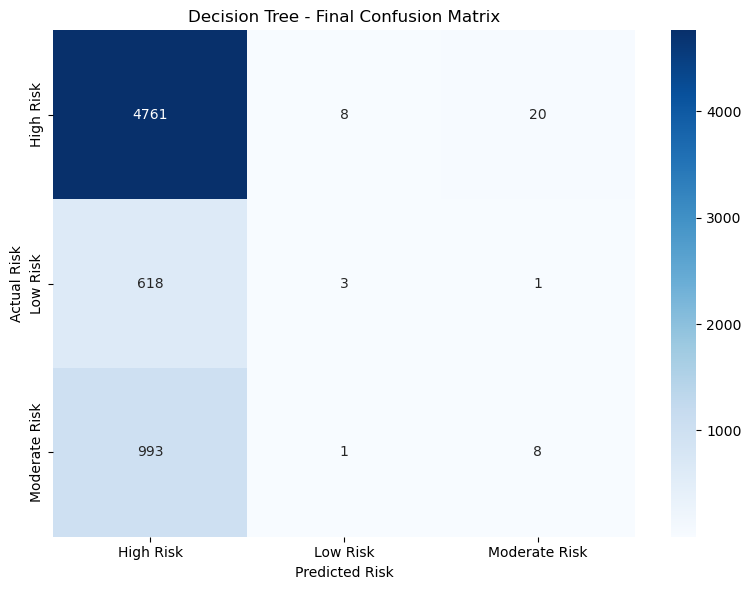

In [81]:
cm_clean = confusion_matrix(
    y_test_clean,
    final_clean_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder_clean.classes_,
    yticklabels=label_encoder_clean.classes_
)

plt.title(
    f"{best_clean_model_name} - Final Confusion Matrix"
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [82]:
display(final_clean_comparison)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.7468,0.5577,0.7468,0.6385,0.5000
1,Decision Tree,0.7441,0.6253,0.7441,0.6404,0.5006
2,Optimized Decision Tree,0.7455,0.5913,0.7455,0.6389,0.5057
3,Random Forest,0.6295,0.5969,0.6295,0.6116,0.5031
4,Optimized Random Forest,0.7054,0.5893,0.7054,0.6322,0.4987


In [83]:
# Final Decision Tree Evaluation
# Final Decision Tree predictions

final_dt_predictions = best_tree_clean.predict(
    X_test_clean_processed
)

print("Final Decision Tree Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test_clean,
        final_dt_predictions,
        target_names=label_encoder_clean.classes_
    )
)

Final Decision Tree Classification Report
               precision    recall  f1-score   support

    High Risk       0.75      1.00      0.85      4789
     Low Risk       0.00      0.00      0.00       622
Moderate Risk       0.21      0.00      0.01      1002

     accuracy                           0.75      6413
    macro avg       0.32      0.33      0.29      6413
 weighted avg       0.59      0.75      0.64      6413



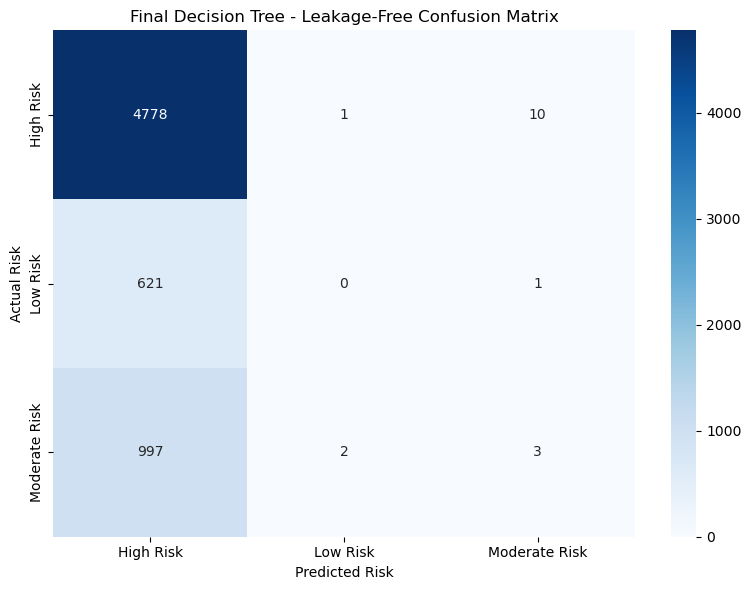

In [84]:
final_dt_cm = confusion_matrix(
    y_test_clean,
    final_dt_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    final_dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder_clean.classes_,
    yticklabels=label_encoder_clean.classes_
)

plt.title(
    "Final Decision Tree - Leakage-Free Confusion Matrix"
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.tight_layout()
plt.show()

In [85]:
final_dt_feature_names = (
    preprocessor_clean
    .get_feature_names_out()
)

final_dt_importance = pd.DataFrame({
    "Feature": final_dt_feature_names,
    "Importance": best_tree_clean.feature_importances_
})

final_dt_importance = final_dt_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    final_dt_importance.head(15)
)

,Feature,Importance
13,num__route_risk_level,0.244662
9,num__lead_time_days,0.135056
8,num__supplier_reliability_score,0.132092
10,num__historical_demand,0.087128
4,num__handling_equipment_availability,0.086032
1,num__traffic_congestion_level,0.080512
11,num__iot_temperature,0.073977
16,num__fatigue_monitoring_score,0.056911
2,num__warehouse_inventory_level,0.055128
6,num__port_congestion_level,0.048502


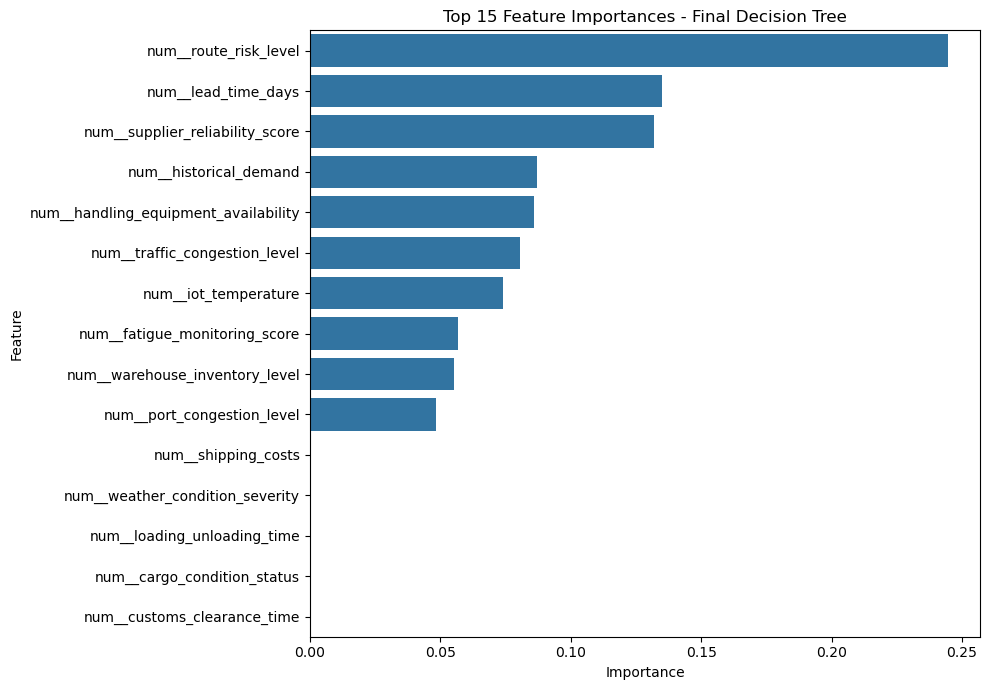

In [86]:
top_final_dt_features = (
    final_dt_importance.head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_final_dt_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances - Final Decision Tree"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [87]:
from sklearn.preprocessing import label_binarize

y_test_binary = label_binarize(
    y_test_clean,
    classes=np.arange(
        len(label_encoder_clean.classes_)
    )
)

dt_probabilities = best_tree_clean.predict_proba(
    X_test_clean_processed
)

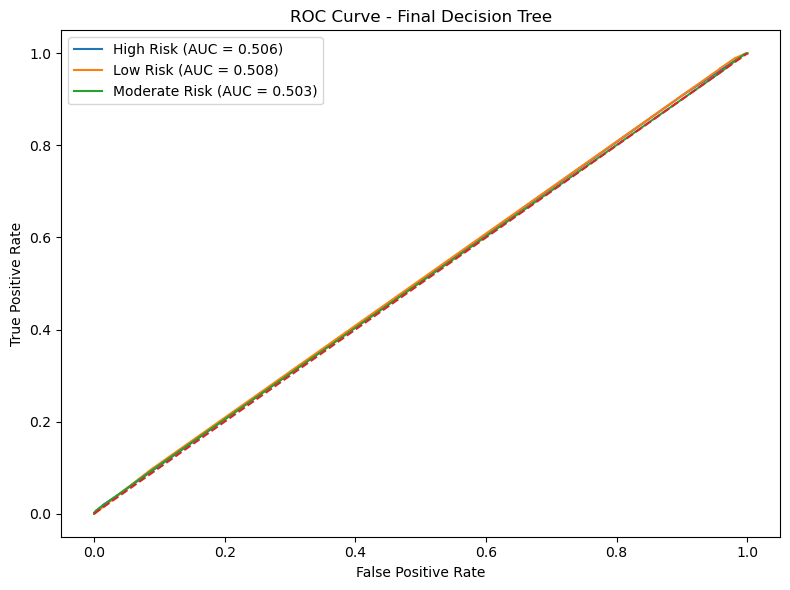

In [88]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(
    label_encoder_clean.classes_
):
    
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        dt_probabilities[:, i]
    )
    
    roc_auc_class = auc(
        fpr,
        tpr
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc_class:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve - Final Decision Tree"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()